# ECG Signal Processing Workshop — Notebook 5: Advanced Consensus Detection

## Overview

Notebook 4 showed that **no single R-peak detector dominates** across
all signal conditions: some excel on clean BIOPAC traces while others
cope better with the noisy, low-amplitude waveforms from the textile
Baby Belt. The natural next step is to *combine* detectors.

NeuroKit2's built-in **PROMAC** (Probabilistic Multi-method Aggregation
Consensus) is a solid baseline, but it treats every detector equally and
uses a fixed Gaussian kernel — assumptions that break down on
textile-electrode ECG where detector reliability varies enormously.

This notebook builds three progressively smarter ensemble strategies:

| Method | Key idea | Advantage |
|---|---|---|
| **PROMAC from scratch** | Equal-weight Gaussian consensus | Simple, no tuning |
| **BIOPAC-weighted consensus** | Weight each detector by its F1 on BIOPAC reference | Leverages known ground truth |
| **SQI-gated detection** | Fast single detector in clean segments, full ensemble only where needed | Computationally efficient + robust |

We also introduce a **kurtosis-based Signal Quality Index (SQI)** to
decide *where* to deploy expensive ensemble processing.

### Notebook outline

1. Imports & file paths
2. Data loading & preprocessing
3. BIOPAC reference peaks
4. PROMAC from scratch (educational implementation)
5. Signal Quality Index (SQI) — kurtosis-based
6. `consensus_peaks` library
7. BIOPAC-weighted consensus
8. SQI-gated detection
9. Cross-correlation sync refinement
10. Final comparison & Bland-Altman analysis
11. Summary & next steps

## 1. Environment Setup

All imports and user-configurable file paths live here so the notebook is
self-contained and easy to adapt to new recordings.

In [25]:
# =====================================================================
# USER CONFIGURATION
# =====================================================================
BIOPAC_FILE_PATH = r"sample_data/BIOPAC_04020062_9_Female_1st.txt"
BELT_FILE_PATH   = r"sample_data/BABY_BELT_04020062_9_Female_1st.csv"
# --- Dataset format selector ---
DATASET_FORMAT = "CAREWEAR"  # Options: "BABY_BELT" or "CAREWEAR"
# --- CareWear paths ---
CAREWEAR_BIOPAC_FILE_PATH = r"sample_data/CAREWEAR/P27-stationaryBike2-biopac-07-02-2025.txt"
CAREWEAR_BELT_FILE_PATH   = r"sample_data/CAREWEAR/P27-stationaryBike2-belt-07-02-2025"
CAREWEAR_BIOPAC_ECG_COL   = "CH9"   # "CH9" (raw ECG) or "CH40" (AHA-filtered)

CAREWEAR_BELT_ECG_MODE = "NORMALIZE"  # "MAX30003" = hardware mV (_max30003_convert); "NORMALIZE" = float cast only, then parser zero-mean / z-score (no bit unpack)

def _max30003_convert(raw_int32):
    """Convert raw MAX30003 FIFO values to millivolts.

    Sign-extend 24-bit ECG word, strip 6 tag bits, scale by
    1000 / (131072 * 20) ≈ 0.000381 mV/count (VREF=1V, GAIN=20).
    Interpolates over invalid (fast-recovery/overflow) samples.
    Returns zero-mean float64 array.
    """
    raw = np.asarray(raw_int32, dtype=np.int64)
    raw_u24 = raw & 0xFFFFFF
    etag = (raw_u24 >> 3) & 0x07
    valid = (etag == 0) | (etag == 2)
    raw_s32 = np.where(raw_u24 >= 0x800000, raw_u24 - 0x1000000, raw_u24).astype(np.int32)
    ecg18 = np.right_shift(raw_s32, 6)
    LSB_MV = 1000.0 / (131072.0 * 20.0)
    mv = ecg18.astype(np.float64) * LSB_MV
    mv[~valid] = np.nan
    nans = np.isnan(mv)
    if nans.any():
        ok = np.where(~nans)[0]
        if len(ok) > 1:
            mv = np.interp(np.arange(len(mv)), ok, mv[ok])
        else:
            mv[:] = 0.0
    mv -= np.mean(mv)
    return mv

CAREWEAR_BELT_ECG_SCALE_FN = (
    _max30003_convert if CAREWEAR_BELT_ECG_MODE == "MAX30003" else None
)
OUTPUT_DIR       = r"outputs/NB05"
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import os
import warnings

from scipy.signal import butter, sosfiltfilt, iirnotch, tf2sos, medfilt, find_peaks, correlate
from scipy.ndimage import gaussian_filter1d
from scipy.stats import kurtosis
from tqdm.notebook import tqdm

import neurokit2 as nk

warnings.filterwarnings("ignore")
np.random.seed(42)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory ready: {os.path.abspath(OUTPUT_DIR)}")

Output directory ready: C:\Users\viggi\Documents\Github\WBL-ECG-processing_workshop\outputs\NB05


## 2. Data Loading & Preprocessing

Parsers, filters, and evaluation helpers are copied inline (identical to
NB01–NB04) so this notebook is fully self-contained.

In [2]:
# -----------------------------------------------------------------
# Parsers
# -----------------------------------------------------------------

def parse_biopac(filepath):
    """Parse BIOPAC AcqKnowledge tab-delimited text export.

    Parameters
    ----------
    filepath : str
        Path to the BIOPAC .txt file.

    Returns
    -------
    df : pd.DataFrame
        Numeric data with columns milliSec, CH1 ... CH47, time_s.
    meta : dict
        Recording metadata (filename, recording_time, fs).
    """
    meta = {}
    with open(filepath, "r") as f:
        lines = f.readlines()
    meta["filename"] = lines[0].strip()
    meta["recording_time"] = lines[2].strip().replace("Recording on: ", "")
    meta["fs"] = 1000
    col_names = [
        "milliSec", "CH1", "CH2", "CH3", "CH40", "CH41", "CH42",
        "CH43", "CH44", "CH45", "CH46", "CH47", "_extra",
    ]
    df = pd.read_csv(
        filepath, sep="\t", skiprows=29, header=None,
        names=col_names, on_bad_lines="skip",
    )
    df = df.drop(columns=["_extra"], errors="ignore")
    df = df.dropna(subset=["CH40"])
    df["time_s"] = df["milliSec"] / 1000.0
    return df, meta


def parse_belt(filepath):
    """Parse Baby Belt BLE-streamed CSV.

    Resamples the jittered BLE stream onto a uniform 100 Hz grid
    via linear interpolation.

    Parameters
    ----------
    filepath : str
        Path to the belt .csv file.

    Returns
    -------
    df : pd.DataFrame
        Raw belt DataFrame.
    ecg_interp : np.ndarray
        Uniformly resampled ECG (ADC counts).
    t_uniform : np.ndarray
        Uniform time vector (seconds).
    fs_nominal : int
        Nominal sampling rate (100 Hz).
    """
    df = pd.read_csv(filepath)
    df["time_s"] = (df["Tx_ms"] - df["Tx_ms"].iloc[0]) / 1000.0
    df["seq_gap"] = df["Seq"].diff() > 1
    fs_nominal = 100
    t_uniform = np.arange(0, df["time_s"].iloc[-1], 1 / fs_nominal)
    ecg_interp = np.interp(t_uniform, df["time_s"].values, df["ECG"].values)
    return df, ecg_interp, t_uniform, fs_nominal


# -----------------------------------------------------------------
# Filters
# -----------------------------------------------------------------

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=5):
    """Zero-phase Butterworth bandpass filter.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.
    fs : int
        Sampling frequency (Hz).
    lowcut, highcut : float
        Passband edges (Hz).
    order : int
        Filter order.

    Returns
    -------
    np.ndarray
        Filtered signal.
    """
    sos = butter(order, [lowcut, highcut], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, signal)


def notch_filter(signal, fs, freq=60.0, quality=30.0):
    """Zero-phase IIR notch filter for powerline removal.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.
    fs : int
        Sampling frequency (Hz).
    freq : float
        Notch centre frequency (Hz).
    quality : float
        Quality factor.

    Returns
    -------
    np.ndarray
        Filtered signal.
    """
    nyquist = fs / 2.0
    if freq >= 0.9 * nyquist:
        print(f'  [notch_filter] Skipping {freq:.0f} Hz notch — '
              f'too close to Nyquist ({nyquist:.0f} Hz) for fs={fs:.0f} Hz')
        return signal
    b, a = iirnotch(freq, quality, fs)
    sos = tf2sos(b, a)
    return sosfiltfilt(sos, signal)


def remove_baseline(signal, fs):
    """Remove baseline wander via cascaded median filters.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.
    fs : int
        Sampling frequency (Hz).

    Returns
    -------
    np.ndarray
        Baseline-corrected signal.
    """
    win1 = int(0.2 * fs) | 1
    win2 = int(0.6 * fs) | 1
    baseline = medfilt(medfilt(signal, win1), win2)
    return signal - baseline


# -----------------------------------------------------------------
# Evaluation
# -----------------------------------------------------------------

def evaluate_rpeaks(ref_peaks, test_peaks, fs, tolerance_ms=50):
    """Evaluate R-peak detection accuracy against a reference.

    Uses a greedy nearest-neighbour matcher with a tolerance window.

    Parameters
    ----------
    ref_peaks : np.ndarray
        Reference R-peak sample indices.
    test_peaks : np.ndarray
        Detected R-peak sample indices.
    fs : int
        Sampling frequency (Hz).
    tolerance_ms : float
        Maximum allowed deviation in milliseconds.

    Returns
    -------
    dict
        Keys: TP, FP, FN, Se, PPV, F1.
    """
    if len(ref_peaks) == 0 or len(test_peaks) == 0:
        return dict(TP=0, FP=len(test_peaks), FN=len(ref_peaks),
                    Se=0.0, PPV=0.0, F1=0.0)

    tol = int(tolerance_ms * fs / 1000)
    tp, fp = 0, 0
    matched = set()

    for p in test_peaks:
        diffs = np.abs(ref_peaks - p)
        idx = np.argmin(diffs)
        if diffs[idx] <= tol and idx not in matched:
            tp += 1
            matched.add(idx)
        else:
            fp += 1

    fn = len(ref_peaks) - len(matched)
    se = tp / (tp + fn + 1e-9)
    ppv = tp / (tp + fp + 1e-9)
    f1 = 2 * se * ppv / (se + ppv + 1e-9)
    return dict(TP=tp, FP=fp, FN=fn,
                Se=round(se, 4), PPV=round(ppv, 4), F1=round(f1, 4))


def bland_altman(ref_rr, test_rr, ax, label="", color="#2196F3"):
    """Draw a Bland-Altman plot on the given axes.

    Parameters
    ----------
    ref_rr : np.ndarray
        Reference RR intervals (ms).
    test_rr : np.ndarray
        Test RR intervals (ms).
    ax : matplotlib.axes.Axes
        Target axes.
    label : str
        Method label for title.
    color : str
        Dot colour.
    """
    n = min(len(ref_rr), len(test_rr))
    r, t = ref_rr[:n], test_rr[:n]
    mean_vals = (r + t) / 2
    diff_vals = t - r
    md = np.mean(diff_vals)
    sd = np.std(diff_vals, ddof=1)

    ax.scatter(mean_vals, diff_vals, s=12, alpha=0.5, color=color, edgecolors="none")
    ax.axhline(md, color="black", linewidth=1, linestyle="-")
    ax.axhline(md + 1.96 * sd, color="red", linewidth=1, linestyle="--")
    ax.axhline(md - 1.96 * sd, color="red", linewidth=1, linestyle="--")

    ylim = max(abs(md - 1.96 * sd), abs(md + 1.96 * sd)) * 1.4
    ax.set_ylim(-ylim if ylim > 0 else -50, ylim if ylim > 0 else 50)

    ax.text(0.02, 0.95, f"Bias = {md:.1f} ms", transform=ax.transAxes,
            fontsize=10, va="top")
    ax.text(0.02, 0.88, f"LoA  = [{md - 1.96*sd:.1f}, {md + 1.96*sd:.1f}] ms",
            transform=ax.transAxes, fontsize=10, va="top")

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean RR (ms)", fontsize=11)
    ax.set_ylabel("Difference (Test \u2212 Ref) (ms)", fontsize=11)


def rr_intervals_ms(peaks, fs):
    """Convert R-peak indices to RR intervals in milliseconds.

    Parameters
    ----------
    peaks : np.ndarray
        R-peak sample indices.
    fs : int
        Sampling frequency (Hz).

    Returns
    -------
    np.ndarray
        RR intervals in milliseconds.
    """
    if len(peaks) < 2:
        return np.array([])
    return np.diff(peaks) / fs * 1000


# ===================== CareWear BIOPAC Parser =====================

def parse_carewear_biopac(filepath, ecg_col=None):
    """Parse CareWear BIOPAC AcqKnowledge exported .txt file.

    Reads a variable-length header, auto-detects sampling rate
    and column layout, returns (df, meta) matching parse_biopac().

    Parameters
    ----------
    filepath : str
        Path to the CareWear BIOPAC .txt export file.
    ecg_col : str or None
        Column to use as primary ECG (default: CAREWEAR_BIOPAC_ECG_COL).

    Returns
    -------
    df : pd.DataFrame
        Numeric data with columns milliSec, CH5, CH9, CH40, etc., time_s.
    meta : dict
        Recording metadata (filename, recording_time, fs).
    """
    if ecg_col is None:
        ecg_col = CAREWEAR_BIOPAC_ECG_COL

    meta = {}
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    meta["filename"] = lines[0].strip()
    sample_rate_ms = None
    header_idx = None

    for idx, line in enumerate(lines):
        stripped = line.strip()
        if not stripped:
            continue
        if "msec/sample" in stripped and sample_rate_ms is None:
            sample_rate_ms = float(stripped.split()[0])
        if stripped.startswith("Recording on:"):
            meta["recording_time"] = stripped.split(": ", 1)[1]
        if stripped.startswith("milliSec"):
            header_idx = idx
            break

    if sample_rate_ms is None:
        raise ValueError("Could not find sample rate (msec/sample) in header.")
    if header_idx is None:
        raise ValueError("Could not find data header row starting with milliSec.")

    meta["fs"] = int(round(1000.0 / sample_rate_ms))

    col_names = [c.strip() for c in lines[header_idx].strip().split("\t") if c.strip()]

    from io import StringIO
    data_text = "".join(lines[header_idx + 2 :])
    df = pd.read_csv(StringIO(data_text), sep="\t", header=None, on_bad_lines="skip")
    df = df.dropna(how="all", axis=1)
    df.columns = col_names[: len(df.columns)]

    if ecg_col not in df.columns:
        raise ValueError(f"ECG column '{ecg_col}' not found. Available: {list(df.columns)}")

    df = df.dropna(subset=[ecg_col])
    df["time_s"] = df["milliSec"] / 1000.0
    return df, meta



# ===================== CareWear Belt Parser =====================

def parse_carewear_belt(filepath, ecg_scale_fn=None):
    """Parse CareWear belt data file (CSV with Unix epoch timestamps).

    Reads the CSV, converts epoch timestamps to relative seconds,
    z-score normalises Channel 4 (ECG), and resamples onto a uniform
    grid.  Returns (df, ecg_interp, t_uniform, fs_nominal) matching
    parse_belt().

    Parameters
    ----------
    filepath : str
        Path to the CareWear belt data file.
    ecg_scale_fn : callable or None
        Optional scaling applied to raw ECG before normalisation.
        Defaults to CAREWEAR_BELT_ECG_SCALE_FN.

    Returns
    -------
    df : pd.DataFrame
        Raw DataFrame with added time_s and seq_gap columns.
    ecg_interp : np.ndarray
        ECG resampled to a uniform grid (z-score normalised).
    t_uniform : np.ndarray
        Uniform time axis in seconds.
    fs_nominal : int
        Estimated sampling rate in Hz.
    Uses CAREWEAR_BELT_ECG_MODE / CAREWEAR_BELT_ECG_SCALE_FN from the config cell:
    MAX30003 applies the FIFO unpack + mV scaling; NORMALIZE skips that and uses
    float Channel 4 values with mean removal and/or z-score in this parser.
"""
    if ecg_scale_fn is None:
        ecg_scale_fn = CAREWEAR_BELT_ECG_SCALE_FN

    df = pd.read_csv(filepath)
    ts = df["timestamp"].values.astype(np.float64)
    df["time_s"] = (ts - ts[0]) / 1000.0

    ecg_raw_int = df["Channel 4"].values.astype(np.int32)
    if ecg_scale_fn is not None:
        ecg_raw = ecg_scale_fn(ecg_raw_int).astype(np.float64)
    else:
        ecg_raw = ecg_raw_int.astype(np.float64)

    ecg_mean, ecg_std = np.mean(ecg_raw), np.std(ecg_raw)
    ecg_norm = (ecg_raw - ecg_mean) / ecg_std if ecg_std > 0 else ecg_raw - ecg_mean

    dt_ms = np.median(np.diff(ts))
    fs_nominal = int(round(1000.0 / dt_ms))

    t_uniform = np.arange(0, df["time_s"].iloc[-1], 1.0 / fs_nominal)
    ecg_interp = np.interp(t_uniform, df["time_s"].values, ecg_norm)
    df["seq_gap"] = False

    return df, ecg_interp, t_uniform, fs_nominal



## 3. Load & Preprocess Both Signals

We apply the same bandpass → notch → baseline-removal pipeline from
NB02, then establish the BIOPAC CH40 reference peaks.

In [3]:
# -----------------------------------------------------------------
# Load data
# -----------------------------------------------------------------
if DATASET_FORMAT == "CAREWEAR":
    biopac_df, biopac_meta = parse_carewear_biopac(CAREWEAR_BIOPAC_FILE_PATH)
    belt_df, belt_ecg_raw, belt_time, belt_fs = parse_carewear_belt(CAREWEAR_BELT_FILE_PATH)
else:
    biopac_df, biopac_meta = parse_biopac(BIOPAC_FILE_PATH)
    belt_df, belt_ecg_raw, belt_time, belt_fs = parse_belt(BELT_FILE_PATH)

biopac_fs = biopac_meta["fs"]

print(f"BIOPAC  : {len(biopac_df)} samples @ {biopac_fs} Hz  "
      f"({biopac_df['time_s'].iloc[-1]:.1f} s)")
_belt_label = "CareWear Belt" if DATASET_FORMAT == "CAREWEAR" else "Baby Belt"
print(f"Belt    : {len(belt_ecg_raw)} samples @ {belt_fs} Hz  "
      f"({belt_time[-1]:.1f} s)")

# -----------------------------------------------------------------
# BIOPAC ECG = CH40 (hardware 0.05–100 Hz AHA). CH1 is sync/aux — not used as ECG.
# Full software pipeline (same order as NB02): notch -> bandpass -> baseline removal.
# -----------------------------------------------------------------
biopac_mask = biopac_df["time_s"] >= 0
if DATASET_FORMAT == "CAREWEAR":
    _ecg_col = CAREWEAR_BIOPAC_ECG_COL
else:
    _ecg_col = "CH40"
biopac_ecg_ch40 = biopac_df.loc[biopac_mask, _ecg_col].values.astype(np.float64)

biopac_ecg_clean = remove_baseline(
    bandpass_filter(
        notch_filter(biopac_ecg_ch40, biopac_fs, 60.0),
        biopac_fs, 0.5, 40.0,
    ),
    biopac_fs,
)

# Belt: same pipeline order (60 Hz notch auto-skips when fs ~100 Hz)
belt_ecg_clean = remove_baseline(
    bandpass_filter(
        notch_filter(belt_ecg_raw, belt_fs, 60.0),
        belt_fs, 0.5, 40.0,
    ),
    belt_fs,
)

# -----------------------------------------------------------------
# BIOPAC reference peaks from CH40 (hardware-filtered)
# -----------------------------------------------------------------
# Reference peaks: NeuroKit2 on the same CH40 full-pipeline signal as the detectors
ref_signals, ref_info = nk.ecg_process(biopac_ecg_clean, sampling_rate=biopac_fs)
ref_peaks = np.where(ref_signals["ECG_R_Peaks"].values == 1)[0]

print(f"\nBIOPAC reference peaks (CH40): {len(ref_peaks)}")
print(f"Mean HR: {60 / (np.mean(np.diff(ref_peaks)) / biopac_fs):.1f} bpm")
print("\nPreprocessing complete.")
# Auto-correct signal inversion: ECG R-peaks should create positive skew.
# If skewness is negative the signal is flipped; invert it.
try:
    from scipy.stats import skew as _ecg_skew
    _bl_skew = float(_ecg_skew(belt_ecg_clean))
    if _bl_skew < 0:
        belt_ecg_clean = -belt_ecg_clean
        print(f"Belt ECG auto-inverted (skewness was {_bl_skew:.2f})")
    else:
        print(f"Belt ECG orientation OK (skewness {_bl_skew:.2f})")
except Exception:
    pass


BIOPAC  : 120001 samples @ 1000 Hz  (119.5 s)
Belt    : 12010 samples @ 100 Hz  (120.1 s)
  [notch_filter] Skipping 60 Hz notch — too close to Nyquist (50 Hz) for fs=100 Hz

BIOPAC reference peaks (CH40): 280
Mean HR: 141.1 bpm

Preprocessing complete.
Belt ECG orientation OK (skewness 0.84)


## 4. Understanding PROMAC

**PROMAC** (Probabilistic Multi-method Aggregation Consensus) works in
four steps:

1. **Run N detectors** independently on the same signal.
2. **Create a binary peak map** for each detector — a vector of zeros
   with ones at detected peak locations.
3. **Convolve each map with a Gaussian kernel** (\u03c3 \u2248 50 ms) to
   spread each peak into a soft probability bump.
4. **Sum the smoothed maps** and detect peaks in the resulting
   probability-like signal above a threshold.

### Limitations for textile ECG

| Limitation | Why it matters |
|---|---|
| **Equal weighting** | A detector with F1 = 0.30 on noisy belt ECG contributes the same as one with F1 = 0.95, diluting the consensus |
| **Fixed kernel width** | A 50 ms Gaussian is fine at 1000 Hz but spans only 5 samples at 100 Hz — too narrow to merge nearby peaks from different detectors |

### PROMAC from Scratch

We implement PROMAC ourselves to see exactly what it does under the
hood, and to have a modifiable baseline for improvements.

In [4]:
def promac_from_scratch(ecg, fs, methods=None):
    """Implement PROMAC consensus from scratch.

    Runs multiple detectors, convolves each binary peak signal with
    a Gaussian kernel, sums them, and detects peaks in the sum.

    Parameters
    ----------
    ecg : np.ndarray
        Preprocessed ECG signal.
    fs : int
        Sampling frequency.
    methods : list or None
        List of neurokit2 method names. Defaults to 5 robust methods.

    Returns
    -------
    consensus_peaks : np.ndarray
        Detected R-peak indices.
    prob_signal : np.ndarray
        Probability-like signal from Gaussian sum.
    detector_peaks : dict
        Individual detector results.
    """
    if methods is None:
        methods = ["neurokit", "pantompkins1985", "hamilton2002",
                   "christov2004", "engzeemod2012"]

    detector_peaks = {}
    for method in tqdm(methods, desc="Running detectors"):
        try:
            _, info = nk.ecg_peaks(ecg, sampling_rate=fs, method=method)
            detector_peaks[method] = np.array(info["ECG_R_Peaks"])
        except Exception as e:
            print(f"  [{method}] failed: {e}")

    sigma = int(0.05 * fs)  # 50 ms Gaussian sigma
    prob_signal = np.zeros(len(ecg))

    for name, peaks in detector_peaks.items():
        binary = np.zeros(len(ecg))
        valid = peaks[(peaks >= 0) & (peaks < len(ecg))]
        binary[valid] = 1
        prob_signal += gaussian_filter1d(binary.astype(float), sigma)

    if prob_signal.max() > 0:
        prob_signal /= prob_signal.max()

    consensus_peaks, _ = find_peaks(prob_signal,
                                     height=0.4,
                                     distance=int(0.3 * fs))
    return consensus_peaks, prob_signal, detector_peaks

### Run PROMAC on Belt ECG

We apply the from-scratch PROMAC to the belt signal and visualise the
probability signal alongside individual detections.

Running detectors:   0%|          | 0/5 [00:00<?, ?it/s]


PROMAC consensus detected 283 peaks
  neurokit            : 283 peaks
  pantompkins1985     : 283 peaks
  hamilton2002        : 282 peaks
  christov2004        : 282 peaks
  engzeemod2012       : 185 peaks


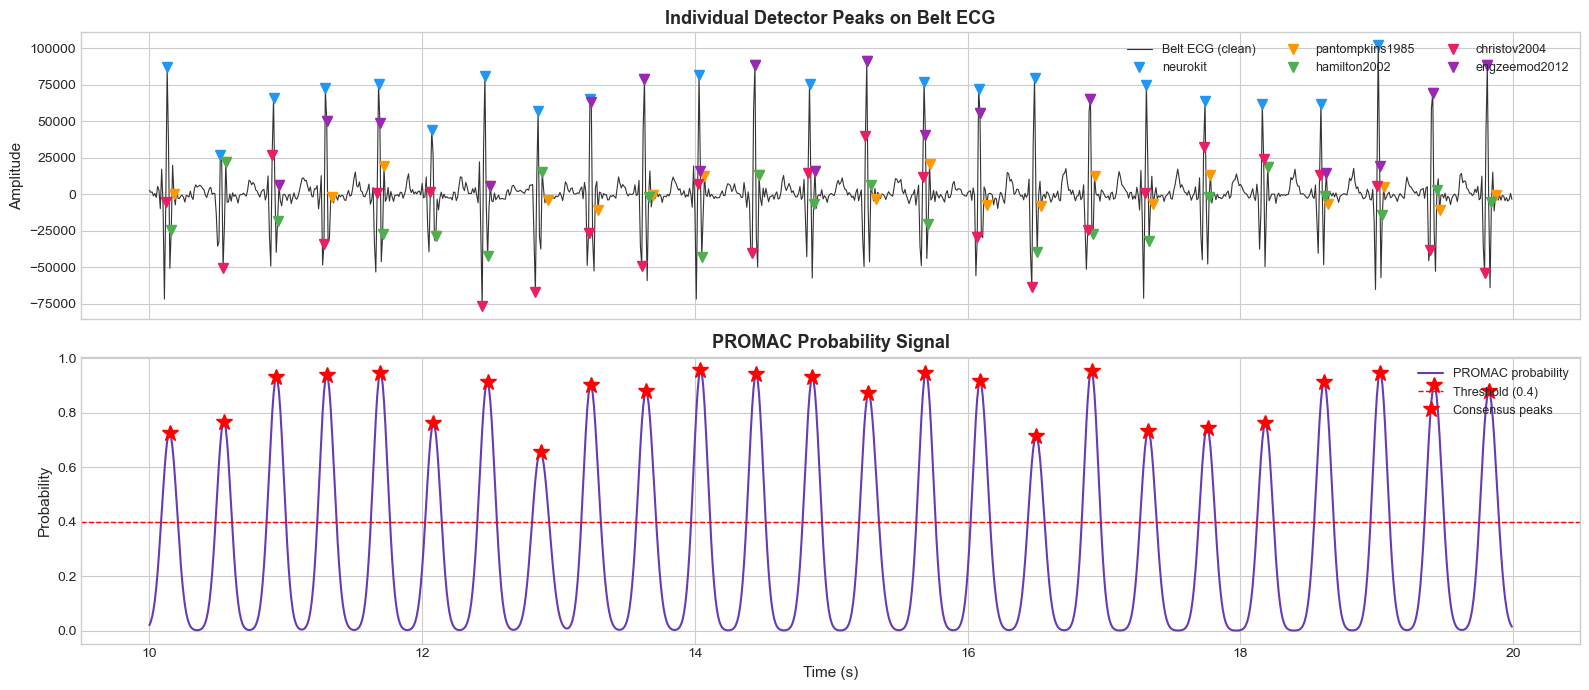

Saved: outputs/NB05\promac_from_scratch.png


In [5]:
promac_peaks, promac_prob, belt_detector_peaks = promac_from_scratch(
    belt_ecg_clean, belt_fs
)

print(f"\nPROMAC consensus detected {len(promac_peaks)} peaks")
for name, pks in belt_detector_peaks.items():
    print(f"  {name:20s}: {len(pks)} peaks")

# -----------------------------------------------------------------
# Visualise: 10-second window
# -----------------------------------------------------------------
t0, t1 = 10, 20
s0, s1 = int(t0 * belt_fs), int(t1 * belt_fs)
t_axis = np.arange(s0, s1) / belt_fs

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(t_axis, belt_ecg_clean[s0:s1], color="#333333", linewidth=0.8,
             label="Belt ECG (clean)")
colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]
for i, (name, pks) in enumerate(belt_detector_peaks.items()):
    mask = (pks >= s0) & (pks < s1)
    axes[0].plot(pks[mask] / belt_fs, belt_ecg_clean[pks[mask]], "v",
                 color=colors[i % len(colors)], markersize=7, label=name)
axes[0].set_ylabel("Amplitude", fontsize=11)
axes[0].set_title("Individual Detector Peaks on Belt ECG", fontsize=13, fontweight="bold")
axes[0].legend(loc="upper right", fontsize=9, ncol=3)

axes[1].plot(t_axis, promac_prob[s0:s1], color="#673AB7", linewidth=1.5,
             label="PROMAC probability")
axes[1].axhline(0.4, color="red", linestyle="--", linewidth=1, label="Threshold (0.4)")
pmask = (promac_peaks >= s0) & (promac_peaks < s1)
axes[1].plot(promac_peaks[pmask] / belt_fs, promac_prob[promac_peaks[pmask]],
             "r*", markersize=12, label="Consensus peaks")
axes[1].set_ylabel("Probability", fontsize=11)
axes[1].set_xlabel("Time (s)", fontsize=11)
axes[1].set_title("PROMAC Probability Signal", fontsize=13, fontweight="bold")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "promac_from_scratch.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'promac_from_scratch.png')}")

## 5. Signal Quality Index (SQI)

Not all ECG segments are created equal. Motion artefacts, electrode
contact loss, and muscle noise create regions where *every* detector
struggles. Rather than blindly running an expensive ensemble everywhere,
we can measure **signal quality** per window and adapt our strategy.

### Kurtosis-based SQI

The kurtosis of an ECG segment is a simple but effective quality proxy:

| Kurtosis range | Interpretation | SQI score |
|---|---|---|
| \u2264 3 | Near-Gaussian — baseline noise, no clear QRS | 1.0 (normal) |
| 3 \u2013 5 | Moderate peakiness — typical clean ECG | 0.7 |
| 5 \u2013 8 | High peakiness — possibly artifact-contaminated | 0.4 |
| > 8 | Extreme spikes — likely motion artifact | 0.1 |

We deliberately invert the usual interpretation: for *R-peak detection*,
a clean ECG with clear QRS peaks has moderate kurtosis (2\u20134), while
spike artifacts push kurtosis very high.

In [6]:
def compute_kurtosis_sqi(signal, fs, window_s=5, stride_s=2.5):
    """Compute kurtosis-based Signal Quality Index per window.

    High kurtosis (>5) suggests artifacts (spikes).
    Normal cardiac kurtosis ~2-4.

    Parameters
    ----------
    signal : np.ndarray
        ECG signal.
    fs : float
        Sampling frequency.
    window_s : float
        Window length in seconds.
    stride_s : float
        Stride in seconds.

    Returns
    -------
    sqi_values : np.ndarray
        SQI score per window (higher = better quality).
    sqi_times : np.ndarray
        Center time of each window.
    """
    win_samples = int(window_s * fs)
    stride_samples = int(stride_s * fs)
    sqi_values = []
    sqi_times = []

    for start in range(0, len(signal) - win_samples, stride_samples):
        window = signal[start:start + win_samples]
        k = kurtosis(window, fisher=True)
        if k > 8:
            sqi = 0.1
        elif k > 5:
            sqi = 0.4
        elif k > 3:
            sqi = 0.7
        else:
            sqi = 1.0
        sqi_values.append(sqi)
        sqi_times.append((start + win_samples / 2) / fs)

    return np.array(sqi_values), np.array(sqi_times)

### SQI Over Time: Belt vs BIOPAC

Comparing the SQI traces reveals which parts of the recording are noisy
on the textile belt but clean on the BIOPAC reference.

Belt windows with SQI < 0.5: 97.9%
Belt  SQI  mean=0.23  min=0.10
BIOPAC SQI mean=0.57  min=0.40


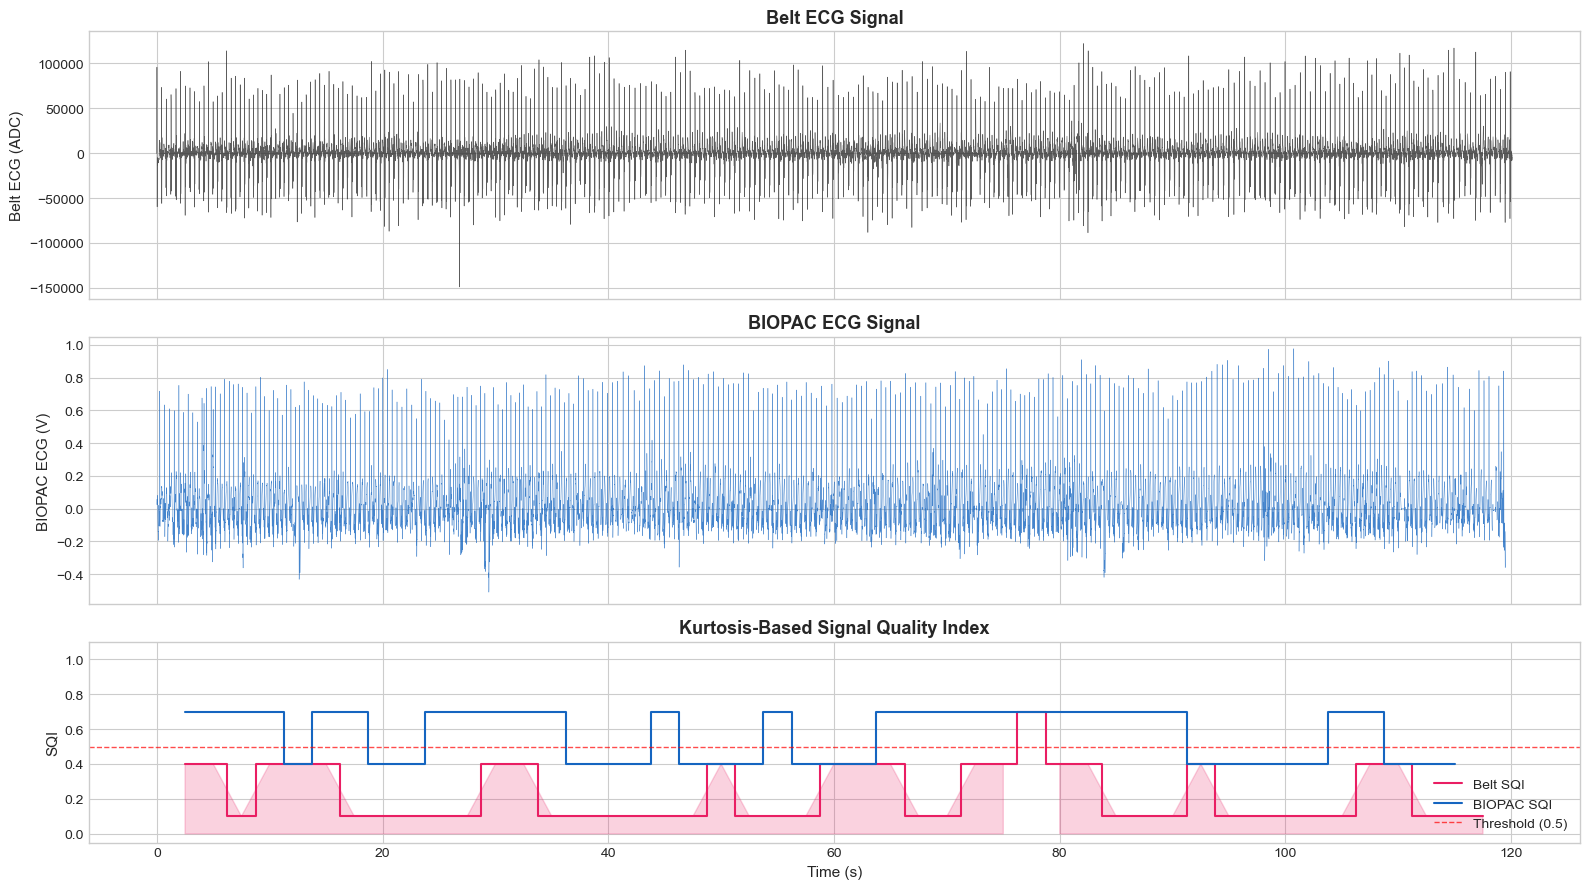

Saved: outputs/NB05\sqi_overview.png


In [7]:
belt_sqi_vals, belt_sqi_times = compute_kurtosis_sqi(belt_ecg_clean, belt_fs)
biopac_sqi_vals, biopac_sqi_times = compute_kurtosis_sqi(biopac_ecg_clean, biopac_fs)

pct_low = np.mean(belt_sqi_vals < 0.5) * 100
print(f"Belt windows with SQI < 0.5: {pct_low:.1f}%")
print(f"Belt  SQI  mean={belt_sqi_vals.mean():.2f}  min={belt_sqi_vals.min():.2f}")
print(f"BIOPAC SQI mean={biopac_sqi_vals.mean():.2f}  min={biopac_sqi_vals.min():.2f}")

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True,
                          gridspec_kw={"height_ratios": [2, 2, 1.5]})

# Belt ECG + SQI
ax_ecg = axes[0]
t_belt = np.arange(len(belt_ecg_clean)) / belt_fs
ax_ecg.plot(t_belt, belt_ecg_clean, color="#333333", linewidth=0.4, alpha=0.8)
ax_ecg.set_ylabel("Belt ECG (ADC)", fontsize=11)
ax_ecg.set_title("Belt ECG Signal", fontsize=13, fontweight="bold")

# BIOPAC ECG
ax_bio = axes[1]
t_bio = np.arange(len(biopac_ecg_clean)) / biopac_fs
ax_bio.plot(t_bio, biopac_ecg_clean, color="#1565C0", linewidth=0.3, alpha=0.8)
ax_bio.set_ylabel("BIOPAC ECG (V)", fontsize=11)
ax_bio.set_title("BIOPAC ECG Signal", fontsize=13, fontweight="bold")

# SQI comparison
ax_sqi = axes[2]
ax_sqi.step(belt_sqi_times, belt_sqi_vals, where="mid", color="#E91E63",
            linewidth=1.5, label="Belt SQI")
ax_sqi.step(biopac_sqi_times, biopac_sqi_vals, where="mid", color="#1565C0",
            linewidth=1.5, label="BIOPAC SQI")
ax_sqi.axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.7,
               label="Threshold (0.5)")
ax_sqi.fill_between(belt_sqi_times, 0, belt_sqi_vals, where=belt_sqi_vals < 0.5,
                     color="#E91E63", alpha=0.2)
ax_sqi.set_ylim(-0.05, 1.1)
ax_sqi.set_ylabel("SQI", fontsize=11)
ax_sqi.set_xlabel("Time (s)", fontsize=11)
ax_sqi.set_title("Kurtosis-Based Signal Quality Index", fontsize=13, fontweight="bold")
ax_sqi.legend(loc="lower right", fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "sqi_overview.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'sqi_overview.png')}")

## 6. `consensus_peaks` Library

The [`consensus_peaks`](https://github.com/danmackinlay/consensus_peaks)
library provides a ready-made implementation of peak consensus with
additional features such as adaptive kernel widths and outlier
rejection. We try it here as a comparison point — if it is not
installed, we gracefully skip.

In [8]:
try:
    # from consensus_peaks import find_consensus_peaks as find_cp
    from consensus_peaks import consensus_detect
    cp_peaks = consensus_detect(belt_ecg_clean, belt_fs)
    cp_peaks = np.array(cp_peaks)
    print(f"consensus_peaks library found {len(cp_peaks)} peaks")
except ImportError:
    print("consensus_peaks not installed. Install with: pip install consensus-peaks")
    print("Falling back to PROMAC result for comparison.")
    cp_peaks = promac_peaks.copy()
except Exception as e:
    print(f"consensus_peaks failed: {e}")
    print("Falling back to PROMAC result for comparison.")
    cp_peaks = promac_peaks.copy()

consensus_peaks failed: module 'scipy.signal' has no attribute 'hamming'
Falling back to PROMAC result for comparison.


## 7. BIOPAC-Weighted Consensus

The key idea: we already **know** how well each detector performs on
BIOPAC-quality ECG (from NB04). Detectors that score high F1 on the
gold standard should contribute more to the consensus.

### Procedure

1. Run all detectors on the **belt** signal.
2. Also run all detectors on the **BIOPAC** signal and evaluate
   against the CH40 reference to get F1 scores.
3. Use each detector's BIOPAC F1 as its **weight** in the Gaussian
   consensus.

This transfers knowledge from the high-quality device to improve
detection on the low-quality device.

In [9]:
def biopac_weighted_consensus(detector_peaks_dict, detector_scores_dict,
                               signal_length, fs, sigma_ms=50):
    """Build consensus using detector weights from BIOPAC evaluation.

    Each detector's contribution is weighted by its F1 score on
    BIOPAC reference data. Peaks are convolved with Gaussians
    and summed with weights.

    Parameters
    ----------
    detector_peaks_dict : dict
        {detector_name: peak_indices_array}
    detector_scores_dict : dict
        {detector_name: F1_score}
    signal_length : int
        Length of the ECG signal.
    fs : int
        Sampling frequency.
    sigma_ms : float
        Gaussian kernel sigma in milliseconds.

    Returns
    -------
    final_peaks : np.ndarray
        Consensus R-peak indices.
    prob_signal : np.ndarray
        Weighted probability signal.
    """
    sigma = int(sigma_ms * fs / 1000)
    total_weight = sum(detector_scores_dict.values()) + 1e-9
    prob_signal = np.zeros(signal_length)

    for name, peaks in tqdm(detector_peaks_dict.items(), desc="Building consensus"):
        w = detector_scores_dict.get(name, 0.5) / total_weight
        binary = np.zeros(signal_length)
        valid = peaks[(peaks >= 0) & (peaks < signal_length)].astype(int).astype(int)
        binary[valid] = 1
        prob_signal += w * gaussian_filter1d(binary.astype(float), sigma)

    if prob_signal.max() > 0:
        prob_signal /= prob_signal.max()

    final_peaks, _ = find_peaks(prob_signal,
                                height=0.4 * prob_signal.max(),
                                distance=int(0.3 * fs))
    return final_peaks, prob_signal

### Step 1 — Evaluate All Detectors on BIOPAC to Get Weights

We run nine NeuroKit2 detectors on BIOPAC CH40 after the full software pipeline and score
each against the CH40 reference. The resulting F1 scores become the
detector weights.

In [10]:
NK2_METHODS = [
    "neurokit", "pantompkins1985", "hamilton2002",
    "christov2004", "gamboa2008", "elgendi2010",
    "engzeemod2012", "kalidas2017", "rodrigues2021",
]

biopac_detector_results = {}
biopac_f1_scores = {}

for method in tqdm(NK2_METHODS, desc="BIOPAC detectors"):
    try:
        _, info = nk.ecg_peaks(biopac_ecg_clean, sampling_rate=biopac_fs, method=method)
        peaks = np.array(info["ECG_R_Peaks"])
        biopac_detector_results[method] = peaks
        metrics = evaluate_rpeaks(ref_peaks, peaks, biopac_fs)
        biopac_f1_scores[method] = metrics["F1"]
    except Exception as e:
        print(f"  [{method}] failed: {e}")
        biopac_f1_scores[method] = 0.0

print("\nBIOPAC F1 scores (detector weights):")
for name, score in sorted(biopac_f1_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:20s}: F1 = {score:.4f}")

BIOPAC detectors:   0%|          | 0/9 [00:00<?, ?it/s]


BIOPAC F1 scores (detector weights):
  neurokit            : F1 = 0.9982
  kalidas2017         : F1 = 0.9982
  pantompkins1985     : F1 = 0.9964
  rodrigues2021       : F1 = 0.9947
  hamilton2002        : F1 = 0.9893
  engzeemod2012       : F1 = 0.9762
  elgendi2010         : F1 = 0.9551
  christov2004        : F1 = 0.9537
  gamboa2008          : F1 = 0.8430


### Step 2 — Run All Detectors on Belt ECG

In [11]:
belt_all_detector_peaks = {}

for method in tqdm(NK2_METHODS, desc="Belt detectors"):
    try:
        _, info = nk.ecg_peaks(belt_ecg_clean, sampling_rate=belt_fs, method=method)
        belt_all_detector_peaks[method] = np.array(info["ECG_R_Peaks"])
    except Exception as e:
        print(f"  [{method}] failed: {e}")
        belt_all_detector_peaks[method] = np.array([])

print(f"\nDetectors with peaks: {sum(1 for v in belt_all_detector_peaks.values() if len(v) > 0)}/{len(NK2_METHODS)}")

Belt detectors:   0%|          | 0/9 [00:00<?, ?it/s]

  [gamboa2008] failed: index 0 is out of bounds for axis 0 with size 0

Detectors with peaks: 8/9


### Step 3 — Weight Visualization

A horizontal bar chart of F1 scores per detector shows how much each
detector contributes to the weighted consensus.

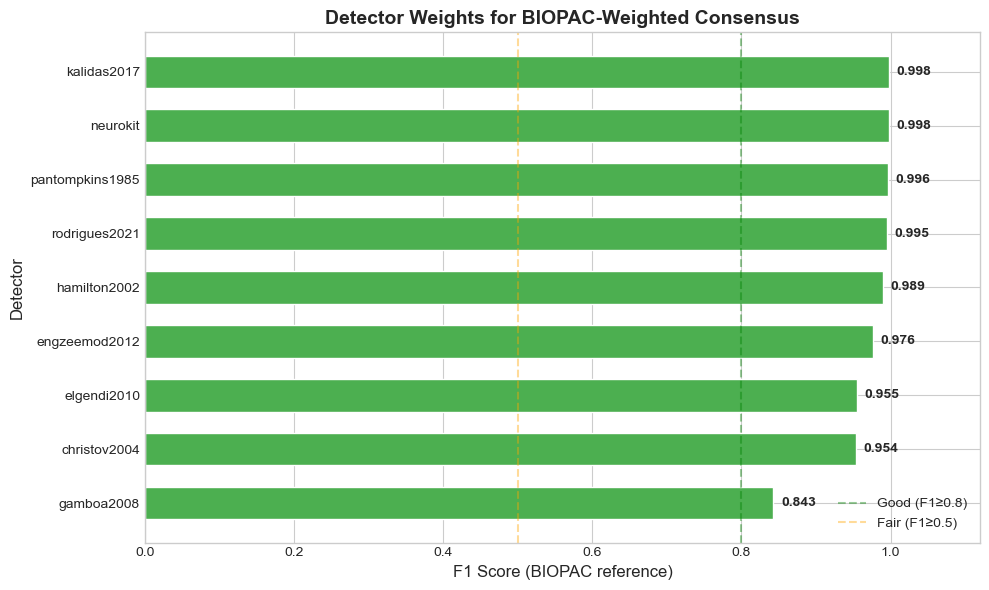

Saved: outputs/NB05\detector_weights.png


In [12]:
sorted_methods = sorted(biopac_f1_scores.keys(), key=lambda x: biopac_f1_scores[x])
sorted_f1 = [biopac_f1_scores[m] for m in sorted_methods]

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#4CAF50" if f >= 0.8 else "#FF9800" if f >= 0.5 else "#F44336"
              for f in sorted_f1]
bars = ax.barh(sorted_methods, sorted_f1, color=bar_colors, edgecolor="white",
               height=0.6)

for bar, val in zip(bars, sorted_f1):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(0, 1.12)
ax.set_xlabel("F1 Score (BIOPAC reference)", fontsize=12)
ax.set_ylabel("Detector", fontsize=12)
ax.set_title("Detector Weights for BIOPAC-Weighted Consensus",
             fontsize=14, fontweight="bold")
ax.axvline(0.8, color="green", linestyle="--", alpha=0.4, label="Good (F1\u22650.8)")
ax.axvline(0.5, color="orange", linestyle="--", alpha=0.4, label="Fair (F1\u22650.5)")
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "detector_weights.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'detector_weights.png')}")

### Step 4 — Apply BIOPAC-Weighted Consensus

Building consensus:   0%|          | 0/9 [00:00<?, ?it/s]

BIOPAC-weighted consensus detected 283 peaks


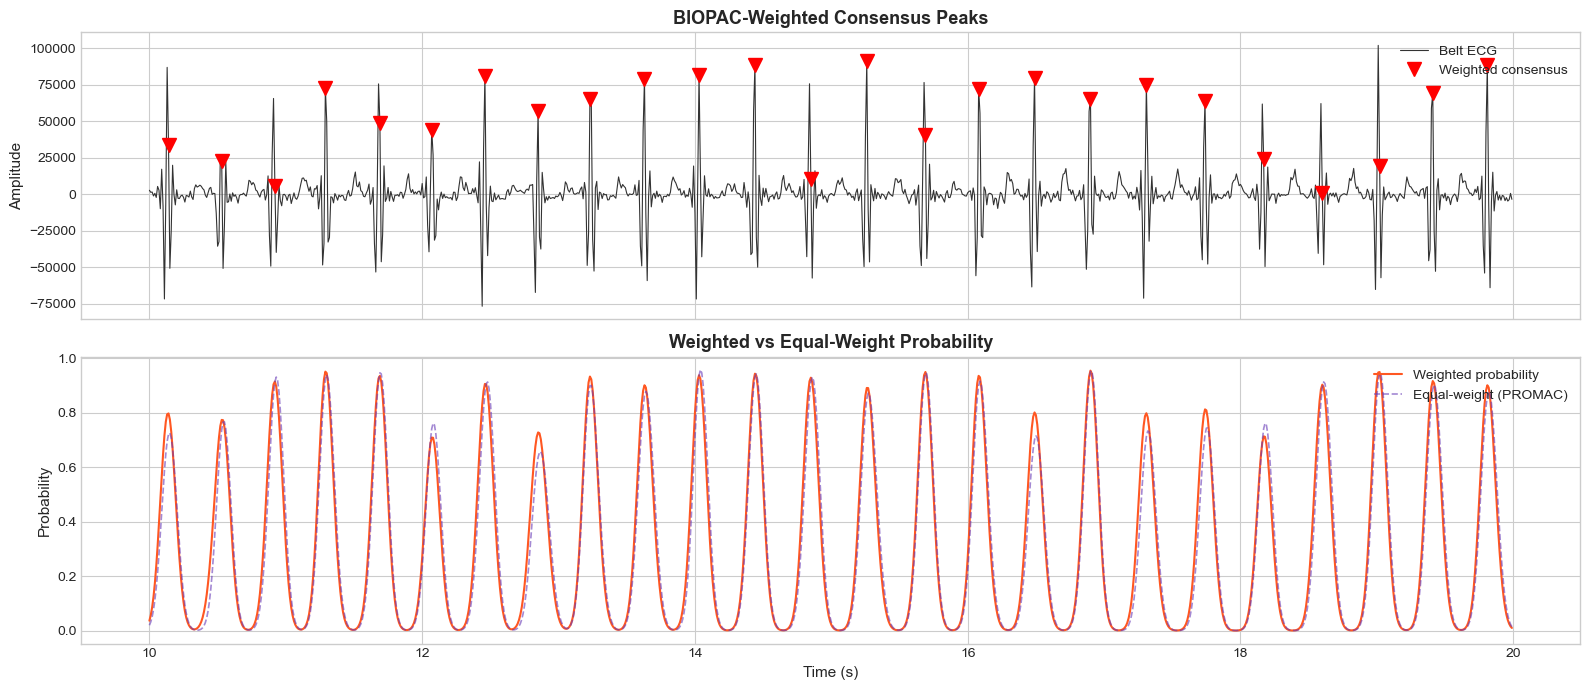

Saved: outputs/NB05\biopac_weighted_consensus.png


In [13]:
weighted_peaks, weighted_prob = biopac_weighted_consensus(
    belt_all_detector_peaks, biopac_f1_scores,
    signal_length=len(belt_ecg_clean), fs=belt_fs, sigma_ms=50
)

print(f"BIOPAC-weighted consensus detected {len(weighted_peaks)} peaks")

# Visualise probability signal
t0, t1 = 10, 20
s0, s1 = int(t0 * belt_fs), int(t1 * belt_fs)
t_axis = np.arange(s0, s1) / belt_fs

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(t_axis, belt_ecg_clean[s0:s1], color="#333333", linewidth=0.8,
             label="Belt ECG")
wmask = (weighted_peaks >= s0) & (weighted_peaks < s1)
axes[0].plot(weighted_peaks[wmask] / belt_fs, belt_ecg_clean[weighted_peaks[wmask]],
             "rv", markersize=10, label="Weighted consensus")
axes[0].set_ylabel("Amplitude", fontsize=11)
axes[0].set_title("BIOPAC-Weighted Consensus Peaks", fontsize=13, fontweight="bold")
axes[0].legend(loc="upper right", fontsize=10)

axes[1].plot(t_axis, weighted_prob[s0:s1], color="#FF5722", linewidth=1.5,
             label="Weighted probability")
axes[1].plot(t_axis, promac_prob[s0:s1], color="#673AB7", linewidth=1.2,
             alpha=0.6, linestyle="--", label="Equal-weight (PROMAC)")
axes[1].set_ylabel("Probability", fontsize=11)
axes[1].set_xlabel("Time (s)", fontsize=11)
axes[1].set_title("Weighted vs Equal-Weight Probability", fontsize=13, fontweight="bold")
axes[1].legend(loc="upper right", fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "biopac_weighted_consensus.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'biopac_weighted_consensus.png')}")

## 8. SQI-Gated Detection

Running a full ensemble is computationally expensive. If the signal is
clean, a single fast detector suffices. We only deploy the weighted
ensemble on **low-quality** segments identified by SQI.

### Strategy

| SQI | Strategy | Rationale |
|---|---|---|
| \u2265 0.5 | Single fast detector (`neurokit`) | Clean signal, cheap |
| < 0.5 | Full BIOPAC-weighted ensemble | Noisy signal needs redundancy |

In [14]:
def sqi_gated_detector(ecg, fs, sqi_values, sqi_times, sqi_threshold=0.5,
                        detector_peaks_dict=None, detector_scores_dict=None):
    """Apply different detection strategies based on signal quality.

    High-SQI segments: single fast detector (neurokit default).
    Low-SQI segments: full weighted ensemble.

    Parameters
    ----------
    ecg : np.ndarray
        Preprocessed ECG signal.
    fs : int
        Sampling frequency.
    sqi_values : np.ndarray
        SQI per window.
    sqi_times : np.ndarray
        Center times of SQI windows.
    sqi_threshold : float
        Below this = low quality.
    detector_peaks_dict : dict
        Pre-computed detector peaks for ensemble.
    detector_scores_dict : dict
        F1 weights for ensemble.

    Returns
    -------
    final_peaks : np.ndarray
        Detected R-peak indices.
    strategy_map : np.ndarray
        Array same length as ecg, 0=fast, 1=ensemble.
    """
    strategy_map = np.zeros(len(ecg))
    for t, sqi in zip(sqi_times, sqi_values):
        half_win = int(2.5 * fs)
        center = int(t * fs)
        s = max(0, center - half_win)
        e = min(len(ecg), center + half_win)
        if sqi < sqi_threshold:
            strategy_map[s:e] = 1

    try:
        _, fast_info = nk.ecg_peaks(ecg, sampling_rate=fs, method="neurokit")
        fast_peaks = np.array(fast_info["ECG_R_Peaks"])
    except Exception:
        fast_peaks = np.array([])

    if detector_peaks_dict and detector_scores_dict:
        ensemble_peaks, _ = biopac_weighted_consensus(
            detector_peaks_dict, detector_scores_dict, len(ecg), fs)
    else:
        ensemble_peaks = fast_peaks

    final_peaks = []
    for p in fast_peaks:
        if 0 <= p < len(strategy_map) and strategy_map[p] == 0:
            final_peaks.append(p)
    for p in ensemble_peaks:
        if 0 <= p < len(strategy_map) and strategy_map[p] == 1:
            final_peaks.append(p)

    final_peaks = np.sort(np.unique(final_peaks))

    if len(final_peaks) > 1:
        cleaned = [final_peaks[0]]
        for p in final_peaks[1:]:
            if p - cleaned[-1] > int(0.2 * fs):
                cleaned.append(p)
        final_peaks = np.array(cleaned)

    return final_peaks, strategy_map

### Run SQI-Gated Detection

Building consensus:   0%|          | 0/9 [00:00<?, ?it/s]

SQI-gated detection: 283 peaks
  Segments using ensemble: 99.9%
  Segments using fast detector: 0.1%


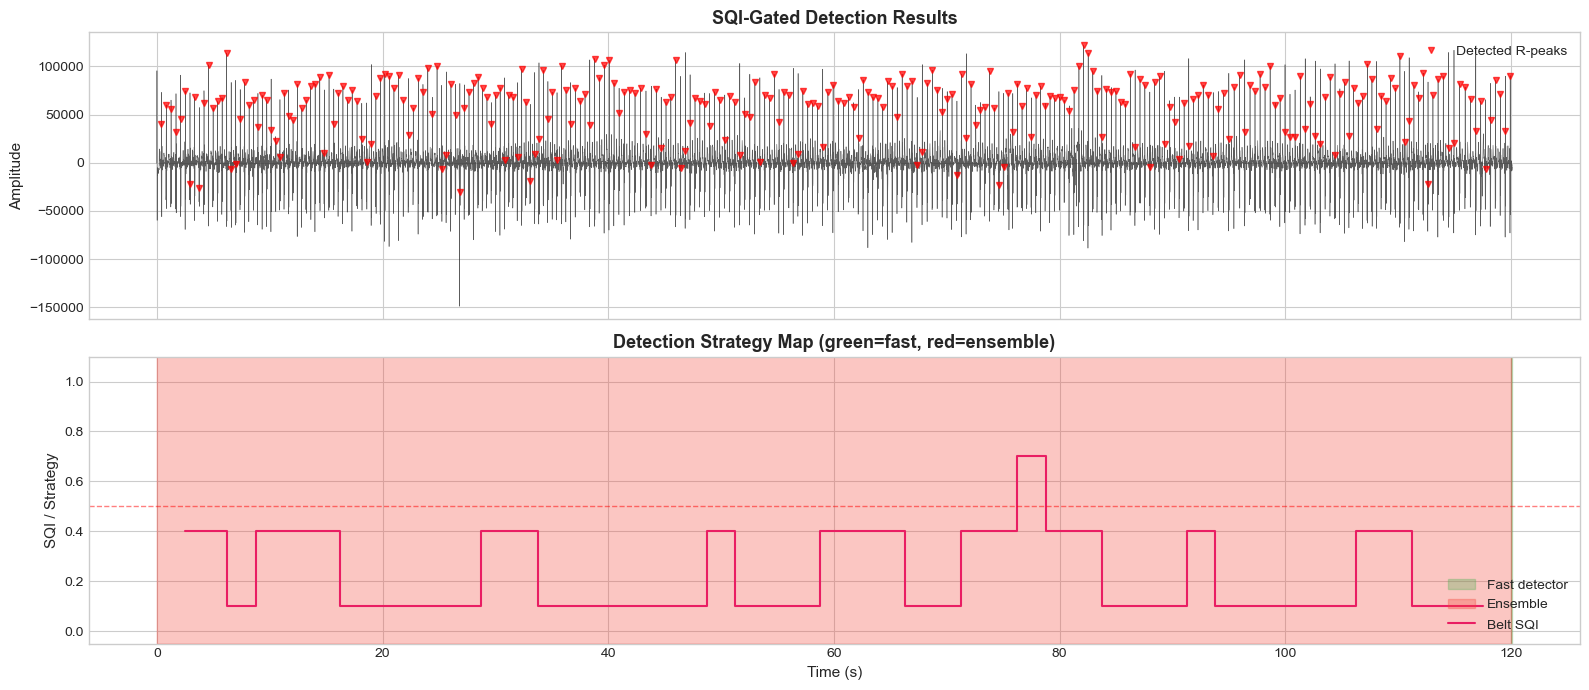

Saved: outputs/NB05\sqi_gated_detection.png


In [15]:
sqi_peaks, strategy_map = sqi_gated_detector(
    belt_ecg_clean, belt_fs,
    belt_sqi_vals, belt_sqi_times,
    sqi_threshold=0.5,
    detector_peaks_dict=belt_all_detector_peaks,
    detector_scores_dict=biopac_f1_scores
)

pct_ensemble = np.mean(strategy_map == 1) * 100
print(f"SQI-gated detection: {len(sqi_peaks)} peaks")
print(f"  Segments using ensemble: {pct_ensemble:.1f}%")
print(f"  Segments using fast detector: {100 - pct_ensemble:.1f}%")

# -----------------------------------------------------------------
# Colour-coded strategy visualisation
# -----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

t_full = np.arange(len(belt_ecg_clean)) / belt_fs

axes[0].plot(t_full, belt_ecg_clean, color="#333333", linewidth=0.4, alpha=0.8)
sqi_mask_p = (sqi_peaks >= 0) & (sqi_peaks < len(belt_ecg_clean))
axes[0].plot(sqi_peaks[sqi_mask_p] / belt_fs,
             belt_ecg_clean[sqi_peaks[sqi_mask_p]],
             "rv", markersize=4, alpha=0.7, label="Detected R-peaks")
axes[0].set_ylabel("Amplitude", fontsize=11)
axes[0].set_title("SQI-Gated Detection Results", fontsize=13, fontweight="bold")
axes[0].legend(loc="upper right", fontsize=10)

axes[1].fill_between(t_full, 0, 1, where=strategy_map == 0,
                      color="#4CAF50", alpha=0.3, label="Fast detector",
                      transform=axes[1].get_xaxis_transform())
axes[1].fill_between(t_full, 0, 1, where=strategy_map == 1,
                      color="#F44336", alpha=0.3, label="Ensemble",
                      transform=axes[1].get_xaxis_transform())
axes[1].step(belt_sqi_times, belt_sqi_vals, where="mid", color="#E91E63",
             linewidth=1.5, label="Belt SQI")
axes[1].axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.5)
axes[1].set_ylim(-0.05, 1.1)
axes[1].set_ylabel("SQI / Strategy", fontsize=11)
axes[1].set_xlabel("Time (s)", fontsize=11)
axes[1].set_title("Detection Strategy Map (green=fast, red=ensemble)",
                  fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right", fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "sqi_gated_detection.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'sqi_gated_detection.png')}")

## 9. Cross-Correlation Sync Refinement

Before comparing belt peaks to the BIOPAC reference, we refine the
temporal alignment using cross-correlation on the first 30 seconds.
This compensates for any residual drift between the two devices.

In [16]:
def fine_tune_sync(biopac_ecg, belt_ecg_resampled, fs, max_lag_ms=500):
    """Fine-tune synchronization using cross-correlation.

    Parameters
    ----------
    biopac_ecg : np.ndarray
        BIOPAC ECG signal.
    belt_ecg_resampled : np.ndarray
        Belt ECG resampled to BIOPAC sampling rate.
    fs : int
        Common sampling rate.
    max_lag_ms : float
        Maximum lag to search in milliseconds.

    Returns
    -------
    lag_samples : int
        Optimal lag in samples (positive = belt leads).
    lag_ms : float
        Optimal lag in milliseconds.
    correlation : float
        Peak normalized correlation value.
    """
    max_lag = int(max_lag_ms * fs / 1000)
    seg_len = int(30 * fs)
    seg_a = biopac_ecg[:seg_len]
    seg_b = belt_ecg_resampled[:seg_len]

    corr = correlate(seg_a, seg_b, mode="full")
    mid = len(corr) // 2
    search_region = corr[mid - max_lag:mid + max_lag]
    lag_samples = np.argmax(search_region) - max_lag
    lag_ms = lag_samples / fs * 1000

    norm = np.std(seg_a) * np.std(seg_b) * len(seg_a)
    correlation = search_region.max() / (norm + 1e-9)

    return lag_samples, lag_ms, correlation

In [17]:
from scipy.signal import resample

# Resample belt to BIOPAC rate for cross-correlation
target_len = int(len(belt_ecg_clean) * biopac_fs / belt_fs)
belt_resampled = resample(belt_ecg_clean, target_len)

lag_samples, lag_ms, xcorr_val = fine_tune_sync(
    biopac_ecg_clean, belt_resampled, biopac_fs, max_lag_ms=500
)

print(f"Cross-correlation sync result:")
print(f"  Lag       : {lag_samples} samples ({lag_ms:.1f} ms)")
print(f"  Xcorr peak: {xcorr_val:.4f}")
print(f"  Direction : {'belt leads' if lag_samples > 0 else 'BIOPAC leads'}")

Cross-correlation sync result:
  Lag       : -176 samples (-176.0 ms)
  Xcorr peak: 0.2455
  Direction : BIOPAC leads


## 10. Final Comparison

We compare all four consensus methods on the belt signal against
the BIOPAC reference:

1. **PROMAC (from scratch)** — equal-weight Gaussian consensus
2. **`consensus_peaks` library** — third-party implementation
3. **BIOPAC-weighted consensus** — F1-weighted Gaussians
4. **SQI-gated detection** — adaptive strategy by signal quality

### Performance Table

In [18]:
# Convert BIOPAC reference peaks to belt time base for comparison
# Scale ref peaks from BIOPAC sample indices to time, then to belt sample indices
ref_peaks_time = ref_peaks / biopac_fs  # seconds
ref_peaks_belt = np.round(ref_peaks_time * belt_fs).astype(int)
ref_peaks_belt = ref_peaks_belt[(ref_peaks_belt >= 0) & (ref_peaks_belt < len(belt_ecg_clean))]

consensus_methods = {
    "PROMAC (from scratch)": promac_peaks,
    "consensus_peaks lib": cp_peaks,
    "BIOPAC-weighted": weighted_peaks,
    "SQI-gated": sqi_peaks,
}

eval_rows = []
for name, peaks in tqdm(consensus_methods.items(), desc="Evaluating methods"):
    metrics = evaluate_rpeaks(ref_peaks_belt, peaks, belt_fs)
    metrics["Method"] = name
    metrics["N_peaks"] = len(peaks)
    eval_rows.append(metrics)

eval_df = pd.DataFrame(eval_rows).set_index("Method")
eval_df = eval_df[["N_peaks", "TP", "FP", "FN", "Se", "PPV", "F1"]]

print("\n" + "=" * 75)
print("CONSENSUS METHOD COMPARISON — Belt vs BIOPAC Reference")
print("=" * 75)
print(eval_df.to_string())
print("=" * 75)

Evaluating methods:   0%|          | 0/4 [00:00<?, ?it/s]


CONSENSUS METHOD COMPARISON — Belt vs BIOPAC Reference
                       N_peaks  TP   FP   FN   Se  PPV   F1
Method                                                     
PROMAC (from scratch)      283   0  283  280  0.0  0.0  0.0
consensus_peaks lib        283   0  283  280  0.0  0.0  0.0
BIOPAC-weighted            283   0  283  280  0.0  0.0  0.0
SQI-gated                  283   0  283  280  0.0  0.0  0.0


### Performance Heatmap

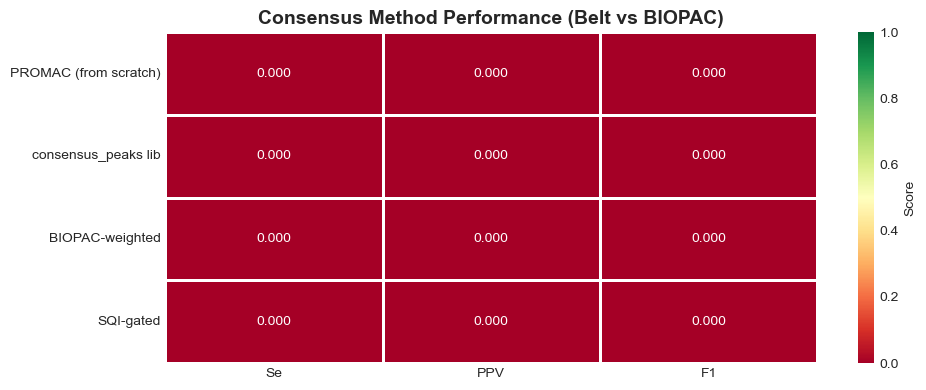

Saved: outputs/NB05\consensus_heatmap.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
hm_data = eval_df[["Se", "PPV", "F1"]].astype(float)
sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.0, vmax=1.0, linewidths=1, linecolor="white",
            cbar_kws={"label": "Score"}, ax=ax)
ax.set_title("Consensus Method Performance (Belt vs BIOPAC)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "consensus_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'consensus_heatmap.png')}")

### Bland-Altman Analysis

For each consensus method we compute RR intervals and draw a
Bland-Altman diagram against the BIOPAC reference.

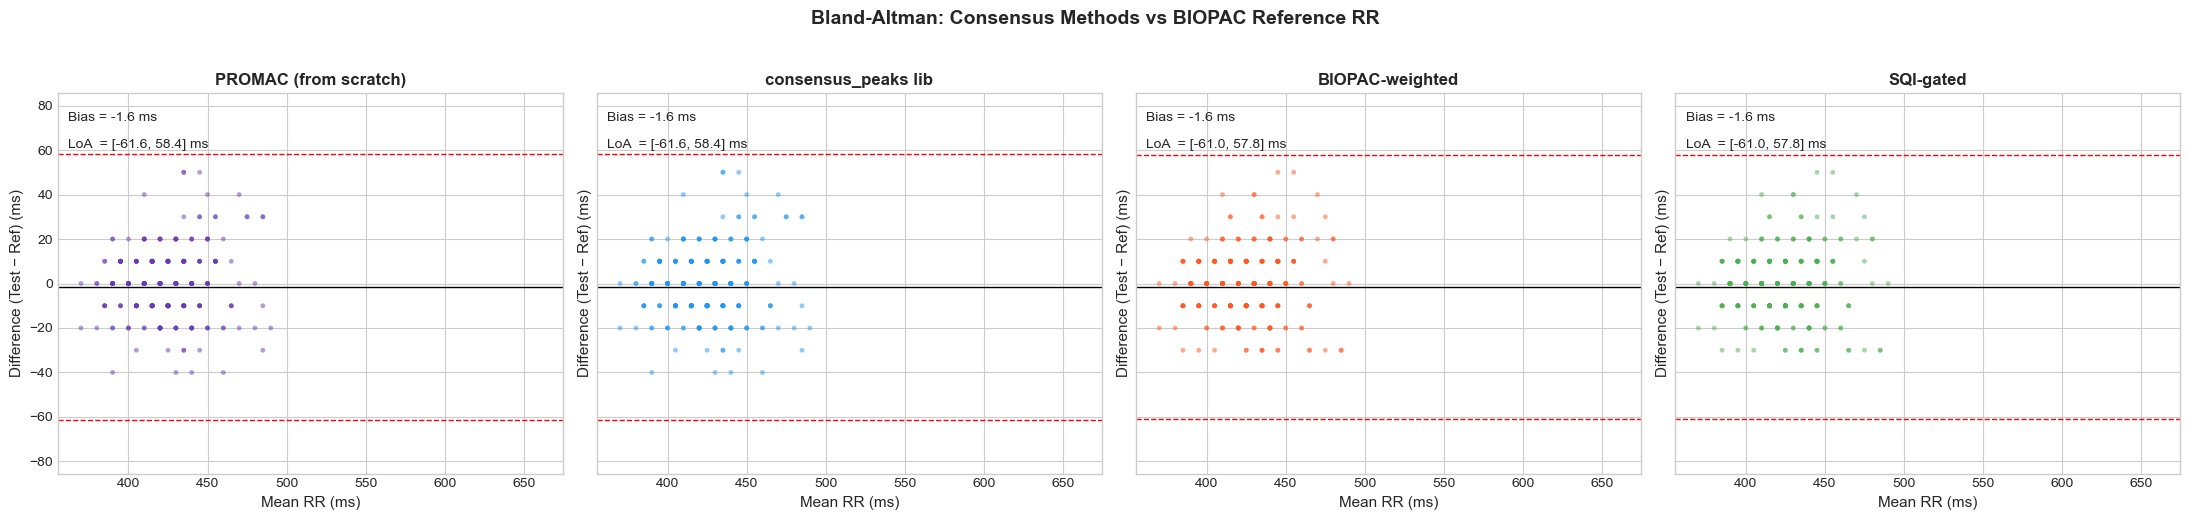

Saved: outputs/NB05\bland_altman_consensus.png


In [20]:
rr_ref = rr_intervals_ms(ref_peaks_belt, belt_fs)

method_names = list(consensus_methods.keys())
ba_colors = ["#673AB7", "#2196F3", "#FF5722", "#4CAF50"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for i, name in enumerate(method_names):
    rr_test = rr_intervals_ms(consensus_methods[name], belt_fs)
    bland_altman(rr_ref, rr_test, axes[i], label=name, color=ba_colors[i])

fig.suptitle("Bland-Altman: Consensus Methods vs BIOPAC Reference RR",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "bland_altman_consensus.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'bland_altman_consensus.png')}")

### R-Peak Overlay (10-second Detail)

Zoom into a 10-second window to visually compare where each consensus
method places its peaks.

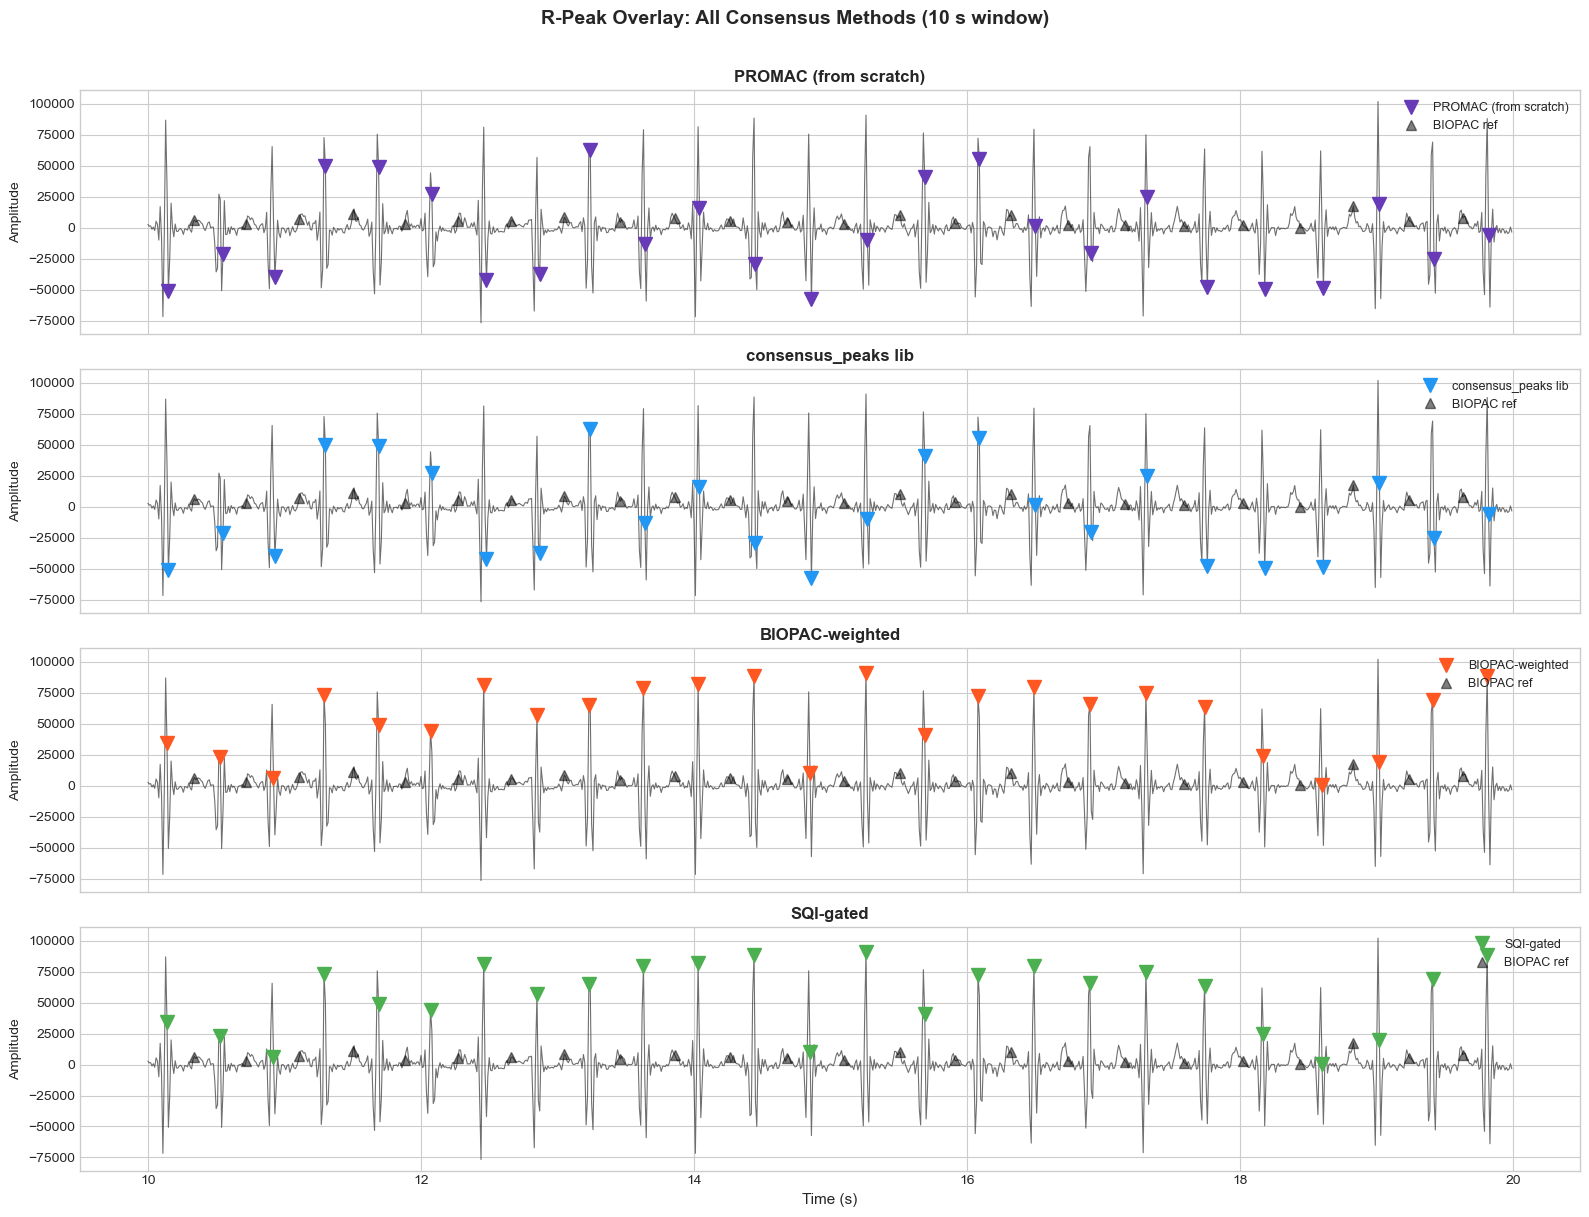

Saved: outputs/NB05\rpeak_overlay_consensus.png


In [21]:
t0, t1 = 10, 20
s0, s1 = int(t0 * belt_fs), int(t1 * belt_fs)
t_axis = np.arange(s0, s1) / belt_fs

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
method_list = list(consensus_methods.items())

for i, (name, peaks) in enumerate(method_list):
    ax = axes[i]
    ax.plot(t_axis, belt_ecg_clean[s0:s1], color="#333333", linewidth=0.8,
            alpha=0.7)
    mask = (peaks >= s0) & (peaks < s1)
    ax.plot(peaks[mask] / belt_fs, belt_ecg_clean[peaks[mask]],
            "v", color=ba_colors[i], markersize=10, label=name)
    ref_mask = (ref_peaks_belt >= s0) & (ref_peaks_belt < s1)
    ax.plot(ref_peaks_belt[ref_mask] / belt_fs,
            belt_ecg_clean[ref_peaks_belt[ref_mask]],
            "k^", markersize=7, alpha=0.5, label="BIOPAC ref")
    ax.set_ylabel("Amplitude", fontsize=10)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle("R-Peak Overlay: All Consensus Methods (10 s window)",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "rpeak_overlay_consensus.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'rpeak_overlay_consensus.png')}")

## 11. Final Summary Performance Table

A combined table of all methods and all metrics, sorted by F1 score.

In [22]:
# Also evaluate individual detectors on belt for context
all_eval_rows = []

for method, peaks in tqdm(belt_all_detector_peaks.items(), desc="Evaluating individuals"):
    metrics = evaluate_rpeaks(ref_peaks_belt, peaks, belt_fs)
    metrics["Method"] = f"[Individual] {method}"
    metrics["N_peaks"] = len(peaks)
    metrics["Type"] = "Individual"
    all_eval_rows.append(metrics)

for name, peaks in consensus_methods.items():
    metrics = evaluate_rpeaks(ref_peaks_belt, peaks, belt_fs)
    metrics["Method"] = f"[Consensus] {name}"
    metrics["N_peaks"] = len(peaks)
    metrics["Type"] = "Consensus"
    all_eval_rows.append(metrics)

summary_df = pd.DataFrame(all_eval_rows)
summary_df = summary_df.sort_values("F1", ascending=False).reset_index(drop=True)
summary_df = summary_df[["Method", "Type", "N_peaks", "TP", "FP", "FN", "Se", "PPV", "F1"]]

print("\n" + "=" * 90)
print("FINAL SUMMARY: All Methods on Belt ECG vs BIOPAC Reference")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_all_methods.csv"), index=False)
print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'summary_all_methods.csv')}")

Evaluating individuals:   0%|          | 0/9 [00:00<?, ?it/s]


FINAL SUMMARY: All Methods on Belt ECG vs BIOPAC Reference
                           Method       Type  N_peaks  TP  FP  FN     Se    PPV     F1
         [Individual] kalidas2017 Individual      282   1 281 279 0.0036 0.0035 0.0036
     [Individual] pantompkins1985 Individual      283   0 283 280 0.0000 0.0000 0.0000
        [Individual] hamilton2002 Individual      282   0 282 280 0.0000 0.0000 0.0000
        [Individual] christov2004 Individual      282   0 282 280 0.0000 0.0000 0.0000
            [Individual] neurokit Individual      283   0 283 280 0.0000 0.0000 0.0000
          [Individual] gamboa2008 Individual        0   0   0 280 0.0000 0.0000 0.0000
         [Individual] elgendi2010 Individual      282   0 282 280 0.0000 0.0000 0.0000
       [Individual] engzeemod2012 Individual      185   0 185 280 0.0000 0.0000 0.0000
       [Individual] rodrigues2021 Individual      265   0 265 280 0.0000 0.0000 0.0000
[Consensus] PROMAC (from scratch)  Consensus      283   0 283 280 0.00

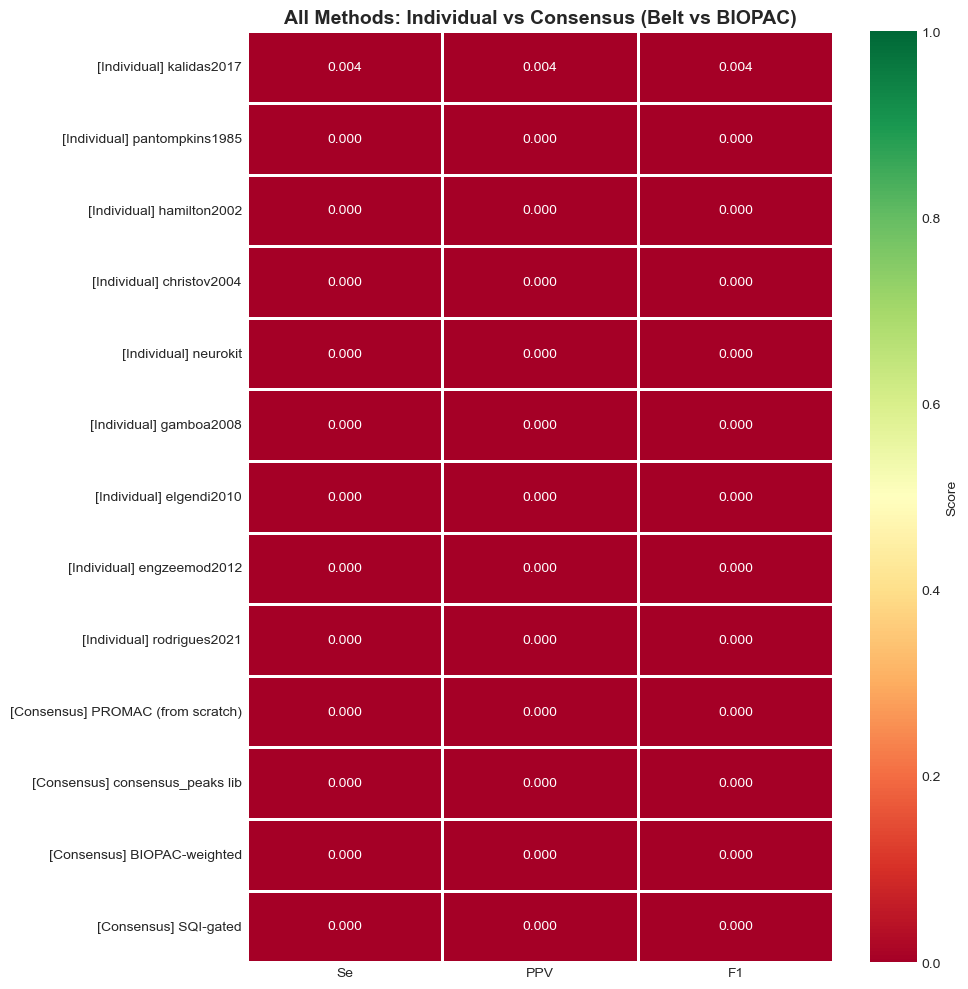

Saved: outputs/NB05\heatmap_all_methods.png


In [23]:
# Final heatmap: all methods
fig, ax = plt.subplots(figsize=(10, 10))

hm_full = summary_df.set_index("Method")[["Se", "PPV", "F1"]].astype(float)
row_colors = ["#E8F5E9" if t == "Consensus" else "#FFF3E0"
              for t in summary_df["Type"]]

sns.heatmap(hm_full, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.0, vmax=1.0, linewidths=0.8, linecolor="white",
            cbar_kws={"label": "Score"}, ax=ax)
ax.set_title("All Methods: Individual vs Consensus (Belt vs BIOPAC)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "heatmap_all_methods.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'heatmap_all_methods.png')}")

## 12. Summary & Next Steps

### Key Findings

1. **PROMAC (equal-weight)** provides a reasonable baseline but treats
   all detectors equally — poor detectors dilute the consensus.

2. **BIOPAC-weighted consensus** leverages the gold-standard device to
   assign detector weights, concentrating influence on algorithms that
   actually work well on ECG data.

3. **SQI-gated detection** adds computational efficiency by only
   deploying the expensive ensemble where the signal is degraded.
   Clean segments use a single fast detector.

4. The kurtosis-based SQI is a useful first-order proxy for signal
   quality but could be refined with template-correlation or
   spectral-power metrics.

### Limitations

- The BIOPAC weights are **session-specific** — they assume the
  relative ranking of detectors is stable across recordings.
- The kurtosis SQI uses fixed thresholds that may need tuning for
  different populations or belt designs.
- Cross-correlation sync assumes a constant offset (no clock drift),
  which may not hold for very long recordings.

### Next: Notebook 6

Notebook 6 will bring everything together into an **end-to-end
pipeline** with the option of deep-learning R-peak detection
(RPNet), performance dashboards, and export for clinical review.